# Exploratory Data Analysis

---

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

---
#### Loading Dataset

In [106]:
dataset = pd.read_csv('Cleaned-Algerian_forest_fires_dataset.csv')
df = dataset
df.head(3)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0


---
#### Removing Unnecessary Columns

In [107]:
# Removing unnecessary columns

df = df.drop(['day', 'month', 'year'], axis=1)

---
#### Encoding of Categories in Classes


In [108]:
df['Classes'] = np.where(df['Classes'].str.contains('not fire'),0,1)
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

---
#### Ploting All Features

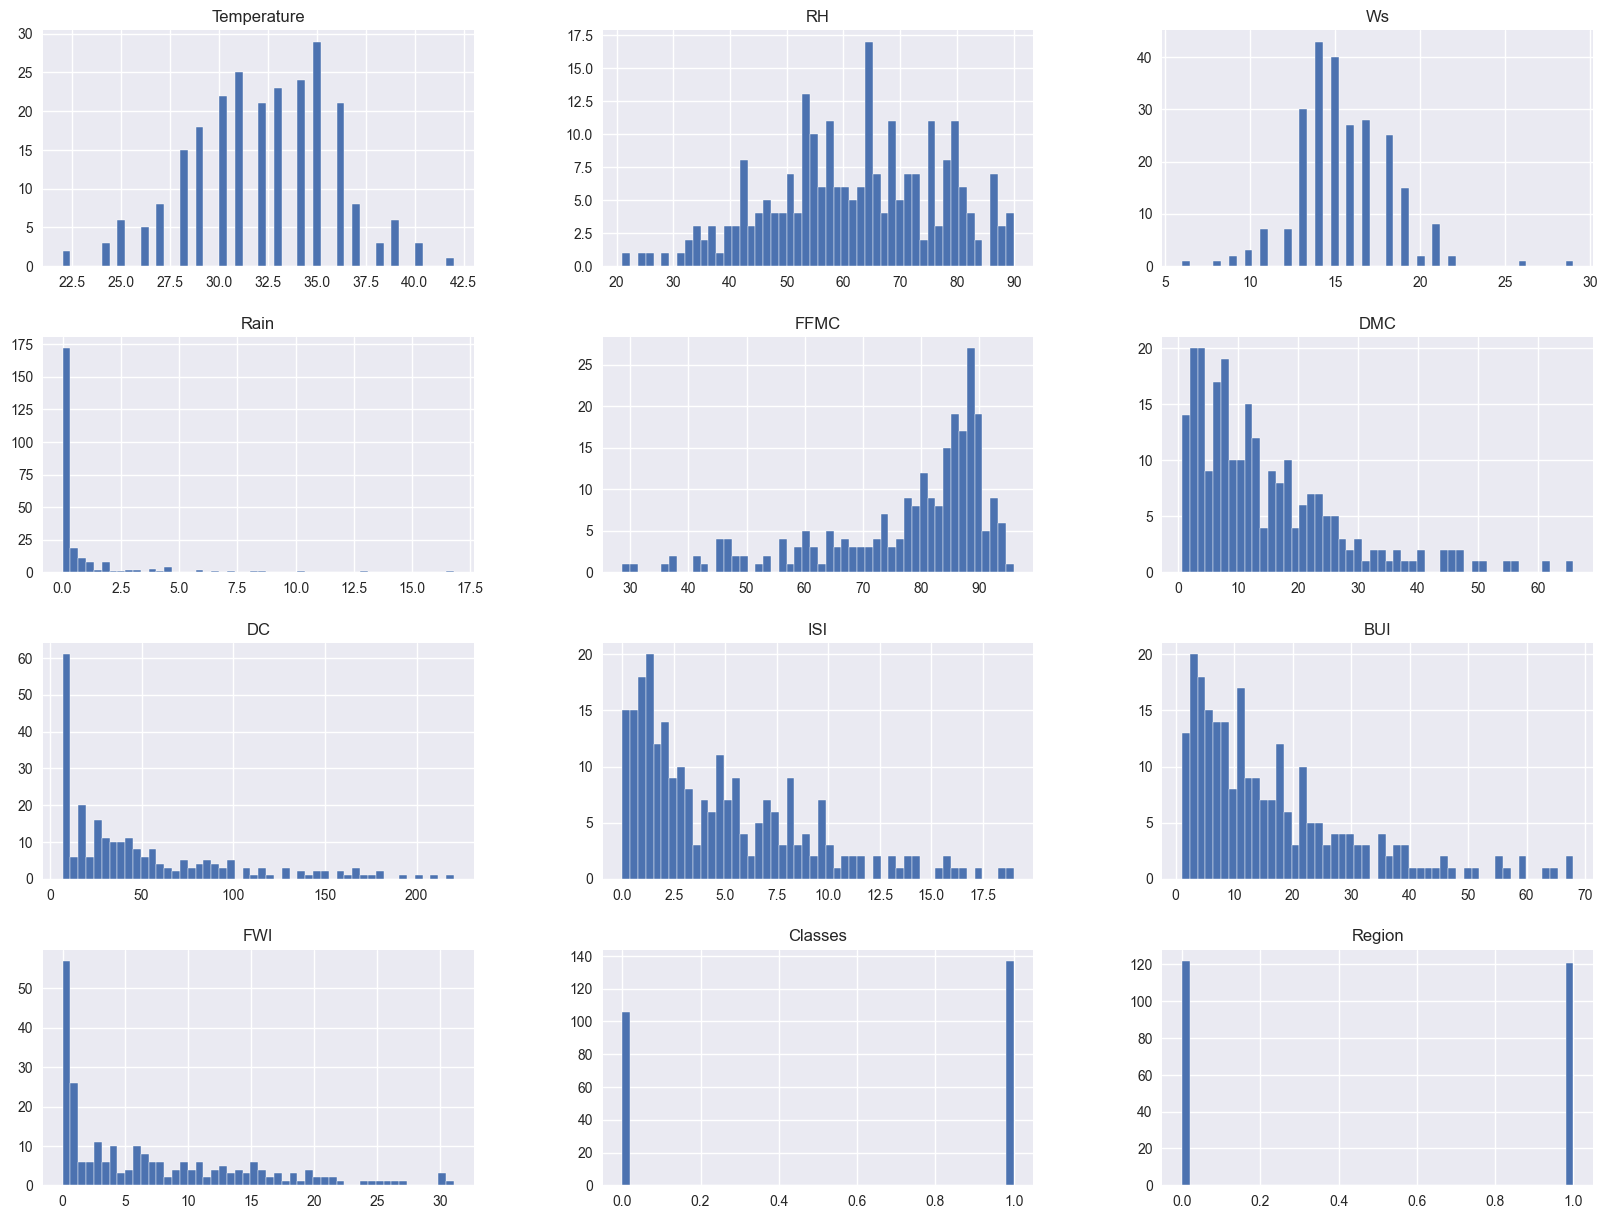

In [109]:
plt.style.use('seaborn-v0_8')
df.hist(bins=50, figsize=(20,15))
plt.show()

---
#### Ploting Pie Chart for Classes

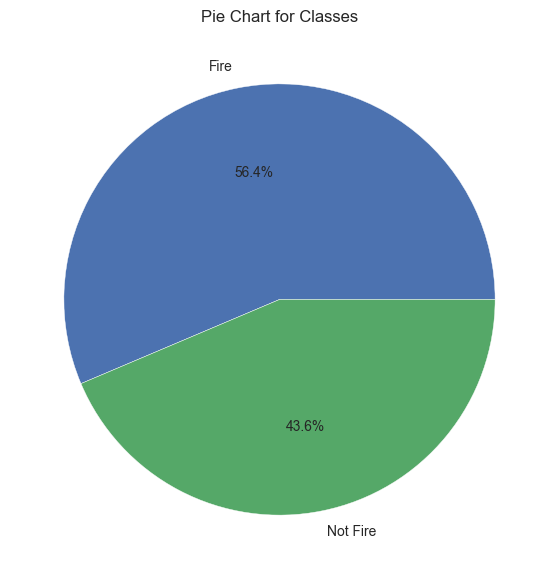

In [110]:
perc = df['Classes'].value_counts(normalize=True)*100

class_lables = ['Fire', 'Not Fire']
plt.figure(figsize=(12,7))
plt.pie(perc, labels=class_lables, autopct='%1.1f%%')
plt.title('Pie Chart for Classes')
plt.show()


---
#### Ploting Correlation for every Features

In [111]:
df.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


<Axes: >

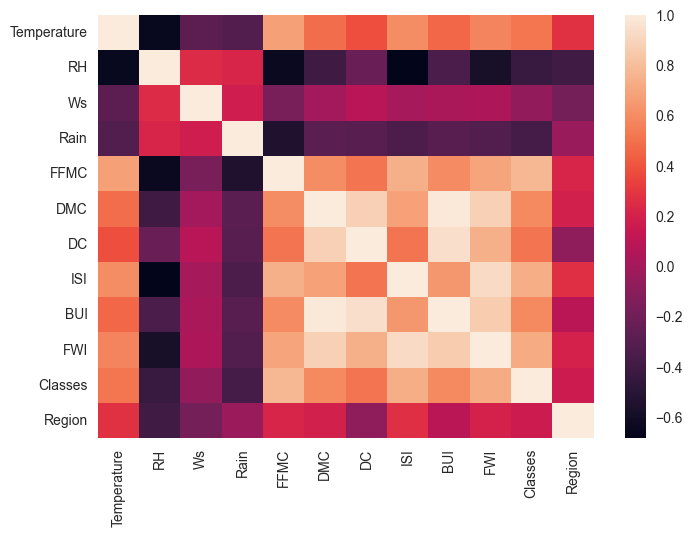

In [112]:
sns.heatmap(df.corr())

---
#### Ploting Box Plot for Outliers in FWI

<Axes: ylabel='FWI'>

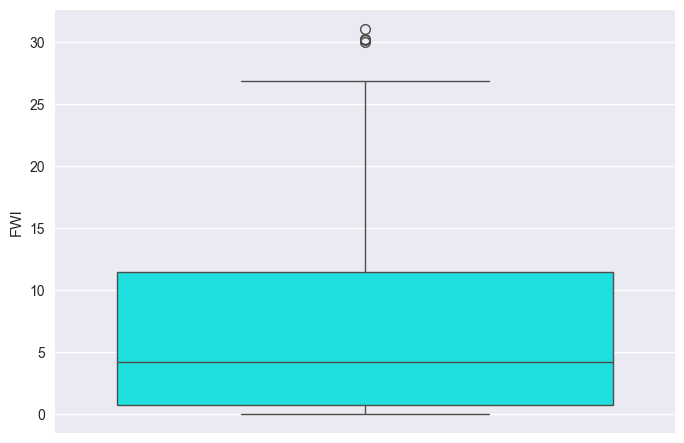

In [113]:
sns.boxplot(df['FWI'], color='cyan')

---
#### Ploting Monthly based Fire Analysis for Region 0 (Sidi - Bel)

Text(0.5, 1.0, 'Fire Analysis of Sidi - Bel Regions')

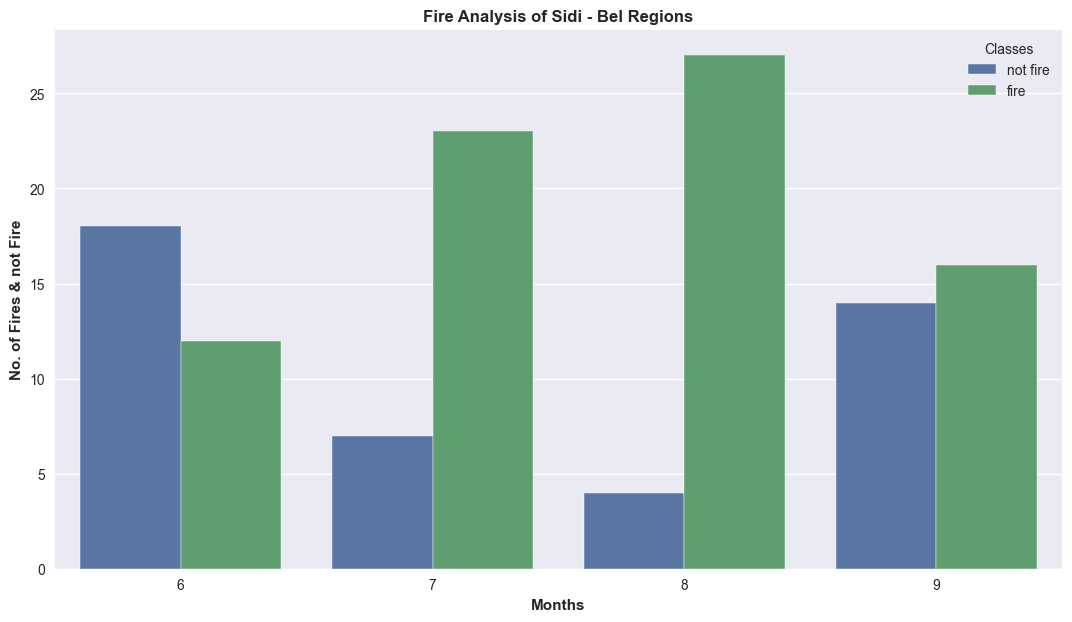

In [114]:
dataset['Classes'] = np.where(dataset['Classes'].str.contains('not fire'), 'not fire', 'fire')

sidi_region = dataset.loc[df['Region']==1]
plt.subplots(figsize=(13,7))
sns.set_style('whitegrid')
sns.countplot(x='month', hue='Classes', data=sidi_region)
plt.xlabel('Months', weight='bold')
plt.ylabel('No. of Fires & not Fire', weight='bold')
plt.title('Fire Analysis of Sidi - Bel Regions', weight='bold')

#### Ploting Monthly based Fire Analysis for Region 1 (Brjaia)


Text(0.5, 1.0, 'Fire Analysis of Brjaia Regions')

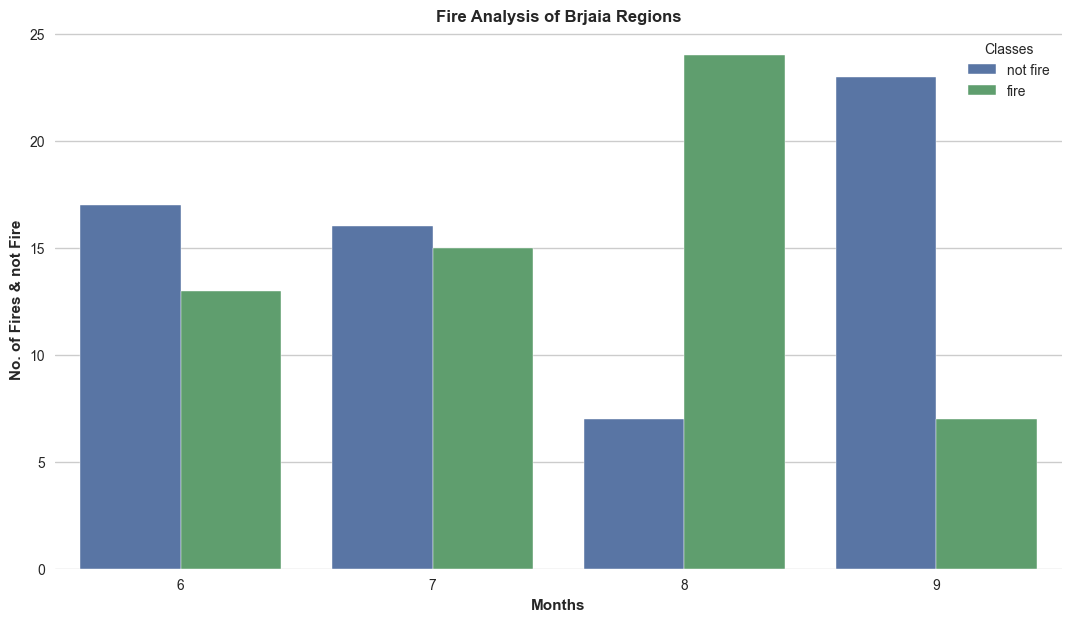

In [115]:
dataset['Classes'] = np.where(dataset['Classes'].str.contains('not fire'), 'not fire', 'fire')


brjaia_region = dataset.loc[df['Region']==0]
plt.subplots(figsize=(13,7))
sns.set_style('whitegrid')
sns.countplot(x='month', hue='Classes', data=brjaia_region)
plt.xlabel('Months', weight='bold')
plt.ylabel('No. of Fires & not Fire', weight='bold')
plt.title('Fire Analysis of Brjaia Regions', weight='bold')

---
#### Observation

- Most No. of Forest Fire happend (July & August)

- Least Fire happend in (June & September)

In [117]:
df.to_csv('Analyzed-Algerian_forest_fires_dataset.csv', index=False)